# Error Probabilities

In hypothesis testing, decisions are based on evidence from random samples. Because samples vary due to chance, statistical tests can sometimes lead to incorrect conclusions. This section examines the role of chance variation and error probabilities in hypothesis testing.

In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

## Wrong Conclusions

If you are testing a null hypothesis against the alternative that the null hypothesis isn't true, then there are four ways of classifying reality and the result of the test.

|     | Test Favors the Null | Test Favors the Alternative |
|----:|:-----------------------|:------------------------|
|**Null is True**| Correct result | Error |
|**Alternative is True**| Error | Correct result |

In two out of the four cells of this table, the test result is wrong. One type of error occurs if the test favors the alternative hypothesis when in fact the null hypothesis is true. The other type of error occurs if the test favors the null hypothesis when in fact the alternative hypothesis is true.

Since the null hypothesis is a completely specified chance model, the first type of error has a chance that we can estimate. The answer turns out to be essentially the cutoff that we use for the p-value. Let's see how.

## The Chance of an Error
Suppose you want to test whether a coin is fair or not. Then the hypotheses are:

**Null:** The coin is fair. That is, the results are like draws made at random with replacement from *Heads, Tails*.

**Alternative:** The coin is not fair.

Suppose you are going to test this hypothesis based on 2000 tosses of the coin. You would expect a fair coin to land heads 1000 times out of 2000, so a reasonable test statistic to use is

$$
\text{test statistic} ~ = ~ \Big\vert ~ \text{number of heads} - 1000 ~ \Big\vert
$$

Small values of this statistic favor the null hypothesis, and large values favor the alternative.

We have simulated this statistic under the null hypothesis many times, and drawn its empirical distribution.

In [2]:
def sample_proportions(sample_size, proportions):
    categories = np.arange(len(proportions))
    sample = np.random.choice(categories, size=sample_size, p=proportions)
    counts = np.bincount(sample, minlength=len(proportions))
    return counts / sample_size

In [3]:
fair_coin = [0.5, 0.5]

In [4]:
def one_simulated_statistic():
    number_of_heads = 2000 * sample_proportions(2000, fair_coin)[0]
    return abs(number_of_heads - 1000)

In [5]:
repetitions = 50000
statistics = np.array([])
for i in np.arange(repetitions):
    statistics = np.append(statistics, one_simulated_statistic())

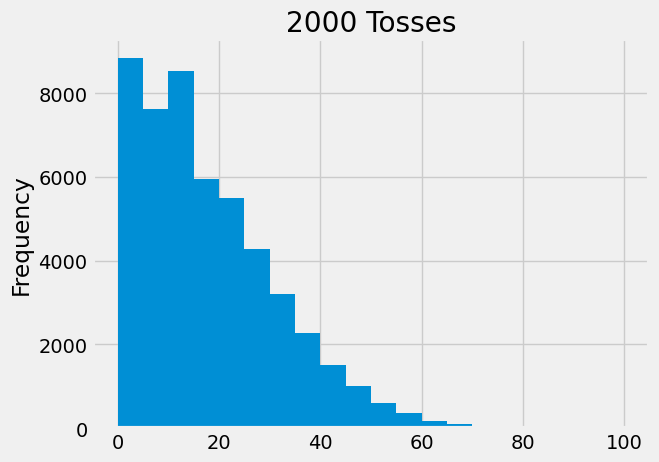

In [10]:
pd.DataFrame({'|Number of Heads - 1000|': statistics})['|Number of Heads - 1000|'].plot.hist(bins=np.arange(0,101,5))
#plt.xlim(45,100)
#plt.ylim(0,2000)
plt.title('2000 Tosses')
plt.show()

The area to the right of 45 is about 5% of the distribution.

In [8]:
np.count_nonzero(statistics >= 45) / repetitions

np.float64(0.04634)

If we use a 5% significance cutoff, our rule would be to reject the null hypothesis whenever the statistic is 45 or greater. However, even a fair coin occasionally produces values this large.

Therefore, if the coin is fair, there is about a 5% chance that the test will incorrectly conclude that the coin is unfair.

## The Cutoff for the p-Value is an Error Probability

A general principle follows:

> If you use a p% cutoff for the p-value and the null hypothesis is actually true, then there is about a p% chance that your test will incorrectly favor the alternative hypothesis.

This is why smaller significance levels such as 1% are considered more conservative than 5%.

## Controlling for Error

In medical trials and other high-stakes settings, researchers often use a 1% significance level to reduce the chance of concluding that a treatment works when it actually has no effect.

Even with a 1% cutoff, chance variation still implies a small probability of reaching an incorrect conclusion.

## Data Snooping and p-Hacking

When many hypotheses are tested using the same dataset, some statistically significant results can appear purely by chance. If researchers report only the significant findings and ignore the rest, the conclusions may be misleading.

This practice is often called *data snooping* or *p-hacking*. Replication by independent researchers is an important safeguard against these problems.

## Technical Note: The Other Kind of Error

There is another possible error: failing to detect a real effect when one exists. Reducing one type of error generally increases the other. Balancing these competing risks is an important topic in statistical inference and experimental design.